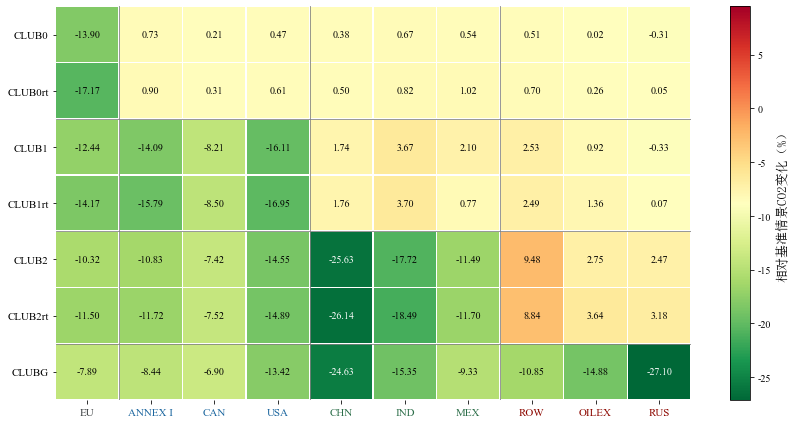

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ 设置全局字体为 Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False  # 负号正常显示

# 文件路径
file_path = 'clubresults0322.xlsx'
sheet_name = 'C_CO2'

# 读取数据
raw_df = pd.read_excel(file_path, sheet_name=sheet_name, index_col=0, usecols="A:K", nrows=7)
raw_df = raw_df.round(2)
df = raw_df.copy()

# ✅ 重新排序情景顺序
# ✅ 重新排列列顺序（国家）
desired_columns = ['EU', 'ANNEX I', 'CAN', 'USA', 'CHN', 'IND', 'MEX', 'ROW', 'OILEX', 'RUS']
df = df[desired_columns]
desired_order = ['CLUB0', 'CLUB0rt', 'CLUB1', 'CLUB1rt', 'CLUB2', 'CLUB2rt', 'CLUBG']
df = df.reindex(desired_order)

# 国家颜色设置
column_colors = {
    'EU': '#393d3f',
    'ANNEX I': '#1a659e',
    'CAN': '#1a659e',
    'USA': '#1a659e',
    'MEX': '#2c6e49',
    'CHN': '#2c6e49',
    'IND': '#2c6e49',
    'ROW': '#8d0801',
    'RUS': '#8d0801',
    'OILEX': '#8d0801'
}
col_colors = [column_colors.get(col, 'black') for col in df.columns]

# 绘图
plt.figure(figsize=(12, 6))
ax = sns.heatmap(df, annot=False, fmt=".2f", cmap='RdYlGn_r', center=0,
                 linewidths=0.5, cbar=False, mask=df.isnull())

# 手动添加 colorbar，并设置 Simsun 字体
norm = plt.Normalize(vmin=df.min().min(), vmax=df.max().max())
sm = plt.cm.ScalarMappable(cmap='RdYlGn_r', norm=norm)
cbar = ax.figure.colorbar(sm, ax=ax)
cbar.set_label("相对基准情景CO2变化（%）", fontname='Simsun', fontweight='bold',fontsize=13)

# 横着写情景名（黑色加粗）
ax.set_yticklabels(df.index, rotation=0, fontsize=11, color='black')

# 国家列标签（加粗 + 彩色）
ax.set_xticklabels(df.columns, rotation=0, fontsize=11)
for ticklabel, color in zip(ax.get_xticklabels(), col_colors):
    ticklabel.set_color(color)

# 手动标注数字
for i in range(df.shape[0]):
    for j in range(df.shape[1]):
        value = df.iloc[i, j]
        if pd.isnull(value):
            continue
        display_text = f"{value:.2f}"
        
        # ✅ 小于 -23 的值用白色字体，其余用黑色
        if value < -23:
            text_color = 'white'
        else:
            text_color = 'black'

        ax.text(j + 0.5, i + 0.5, display_text,
                ha='center', va='center',
                fontsize=10, color=text_color, fontweight='normal')


# 添加三条竖线分组
split_positions = [1, 4, 7]
for pos in split_positions:
    ax.axvline(x=pos, color='gray', linewidth=0.8)
    
# 添加三条横线分组
h_split_positions = [2, 4, 6]
for pos in h_split_positions:
    ax.axhline(y=pos, color='gray', linewidth=0.8)

    # 添加底部 CLUB 分组标注
group_labels = {
    'CLUB0': [0],
    'CLUB1': [1, 2, 3],
    'CLUB2': [4, 5, 6],
}



    
# 美化
plt.title('')
plt.xlabel('')
plt.ylabel('')

plt.tight_layout()
plt.savefig('heatmap_co2_2040.svg', format='svg', bbox_inches='tight')
plt.show()
